In [63]:
class Node():
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

### DFS: In-order (left -> node -> right)

##### You need sorted order out of a BST

##### Compute min-difference

##### Validate BST

##### Convert tree→sorted array

In [ ]:
def inorder(root):
    out = []
    stack = []
    
    curr = root
    while stack or curr:
        while curr:
            stack.append(curr)
            curr = curr.left
        
        node = stack.pop() 
        out.append(node.value)
        curr = node.right
    return out

#### 530. Minimum Absolute Difference in BST
##### Given the root of a BST.
##### Return the minimum absolute difference between the values of any two different nodes in the tree.

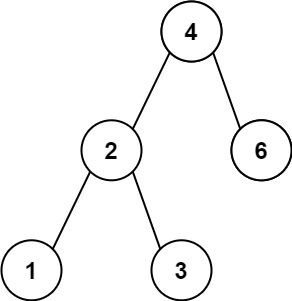

In [ ]:
root = Node(4)
two = Node(2)
six = Node(6)
one = Node(1)
three = Node(3)

# left subtree
root.left = two
two.left = one
two.right = three

# right subtree
root.right = six


In [84]:
def getMinimumDifference(root):
    min_diff = float('inf')
    stack = []
    
    prev, curr = None, root
    while stack or curr:
        while curr:
            stack.append(curr)
            curr = curr.left
        
        curr = stack.pop()
        if prev:
            min_diff = min(min_diff, curr.value - prev.value)
        prev = curr
        curr = curr.right
    
    return min_diff

getMinimumDifference(root)

1

#### 98. Validate Binary Search Tree

##### Given the root of a binary tree, determine if it is a valid BST.

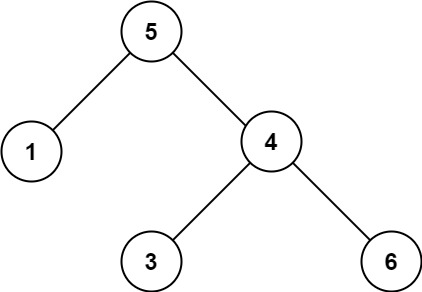

In [91]:
root = Node(5)
one = Node(1)
four = Node(4)
three = Node(3)
six = Node(6)

# left subtree
root.left = one

# right subtree
root.right = four
four.left = three
four.right = six

In [92]:
def isValidBST(root):
    stack = []
    prev, curr = None, root
    while stack or curr:
        while curr:
            stack.append(curr)
            curr = curr.left
        
        node = stack.pop()
        if prev:
            if prev.value > node.value:
                return False
        prev = node
        curr = node.right
    return True

isValidBST(root)

False

### DFS: Pre-order (node -> left -> right)

##### Copy/serialize the tree

##### Evaluate prefix expressions

In [47]:
def preorder(root):
    out = []
    stack = [root]
    
    while stack:
        node = stack.pop()
        out.append(node.value)
        
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return out

#### 938. Range Sum of BST

##### Given the root node of a binary search tree and two integers low and high. 
##### Return the sum of values of all nodes with a value in the inclusive range [low, high].

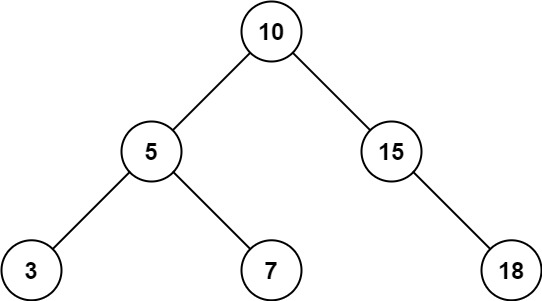

In [122]:
root = Node(10)

five = Node(5)
fifteen = Node(15)

three = Node(3)
seven = Node(7)
eighteen = Node(18)

root.left = five
five.left = three
five.right = seven

root.right = fifteen
fifteen = eighteen

In [123]:
def rangeSumBST(root, low, high):
    out = []
    stack = [root]
    
    while stack:
        node = stack.pop()
        
        if node.value >= low and node.value <= high:
            out.append(node.value)
        
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return sum(out)

rangeSumBST(root, 7, 15)

32

### DFS: Post-order (left -> right -> node)

##### Delete/free nodes bottom-up

##### Compute subtree sizes, heights

In [196]:
def postorder(root):
    if not root: return []
    s1, s2, res = [root], [], []
    while s1:
        node = s1.pop()
        s2.append(node)
        if node.left:  s1.append(node.left)
        if node.right: s1.append(node.right)
    while s2:
        res.append(s2.pop().value)        # visit
    return res


In [124]:
def postorder(root):
    out = []
    stack = [(root, False)]
    
    while stack:
        node, visited = stack.pop()
        
        if visited:
            out.append(node.value)
        else:
            if node != None:
                stack.append((node, True))
                stack.append((node.right, False))
                stack.append((node.left, False))
    return out

In [153]:
root = Node(4)

two = Node(2)
one = Node(1)
three = Node(3)
seven = Node(7)

# left subtree
root.left = two
two.left = one
two.right = three

# right subtree
four.right = seven

In [154]:
def insertIntoBST(root, val):
    # If the tree is empty, the new node becomes the root.
    if root is None:
        return Node(val)

    curr = root
    while curr:
        if val < curr.value:
            # go left
            if curr.left is None:
                curr.left = Node(val)
                break
            else:
                curr = curr.left
        else:
            # go right (this also handles val == curr.value if you allow duplicates on the right)
            if curr.right is None:
                curr.right = Node(val)
                break
            else:
                curr = curr.right

    return root


In [155]:
insertIntoBST(root, 5)

In [158]:
def inorder(root):
    stack = []
    
    curr = root
    while stack or curr:
        while curr:
            stack.append(curr)
            curr = curr.left
        
        node = stack.pop()
        print(node.value)
        curr = node.right

In [159]:
inorder(root)

1
2
3
4
5


#### Closest Binary Search Tree Value

##### Given the root of a binary search tree and a target value, return the value in the BST that is closest to the target. 
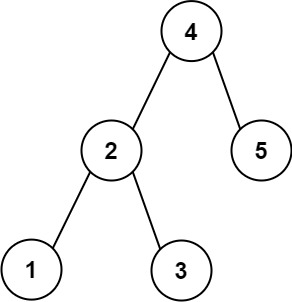

In [193]:
def closestValue(root, target):
    stack = []
    
    prev, curr = None, root
    while stack or curr:
        while curr:
            stack.append(curr)
            curr = curr.left
        
        node = stack.pop()
        if target < node.value and target >= prev.value:
            closest = lambda value: abs(target-value)
            return min(prev.value, node.value, key=closest)
        
        prev = node
        curr = node.right
    
    return closest

In [194]:
root = Node(4)
two = Node(2)
five = Node(5)
one = Node(1)
three = Node(3)

root.left = two
two.left = one
two.right = three

root.right = five

In [195]:
target = 3.714286
closestValue(root, target)

4